# 5'UTR Marker Analysis: NT96 / NT192 / NT384 / human / human_truncated / random

This notebook tests four sequence-derived markers across six sequence groups, reusing the
analysis functions already written in this repository (`src/rna_analysis.py`, `src/constants.py`,
`src/KLD_calculation.py`, `src/rng_sequences.py`):

1. **Nucleotide probabilities** — per-base (A/C/G/U) frequencies and GC content.
2. **uORFs in reading frame** — frame-resolved upstream ORF counts/lengths for 5 (near-)cognate start codons.
3. **Secondary structure / MFE** — sliding-window minimum free energy via ViennaRNA.
4. **Markov (dinucleotide transition) probabilities** — first-order transition matrices + pairwise JSD between groups.

Each marker below follows the same three-step pattern:
**1) write the function (only where one doesn't already exist in `src/`), 2) apply it across all six
groups, 3) plot the result** — with comments explaining each step.

**Data sources:**
- `data/new_dataset.csv` already has an explicit `Group` column and supplies the `human` and `random` groups.
- `data/delivered_twist_pool.csv` has no `Group` column at all — the `human_truncated` sequences are
  mixed in with everything else in the pool and only identifiable by their `transcript_id`: rows
  starting with `"ENST"` (an Ensembl transcript ID) are `human_truncated`; everything else in that
  file is a different design and gets filtered out as a separate step.
- `NT96` / `NT192` / `NT384` don't have a real source wired up yet (TODO, flagged again below) — synthetic
  placeholder sequences stand in for now purely so the rest of the notebook runs end-to-end.

If either real CSV is missing, a small synthetic stand-in is generated instead (using this repo's own
`src.rng_sequences.randomseqs`) so the notebook still runs — replace the relevant block once the real
file is available.


## 0. Setup

In [1]:
import sys, os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append("..")   # matches the convention used in model.ipynb / test.ipynb
sys.path.append(".")

import src.constants as constants
import src.rna_analysis as rna
import src.KLD_calculation as kldcalc
import src.rng_sequences as rngseq

sns.set_style("whitegrid")
plt.rc("font", size=12)

# Marker 3 (MFE) needs ViennaRNA - check it's importable up front so we can skip that section cleanly if not.
try:
    import ViennaRNA as vrna
    MFE_AVAILABLE = True
except ImportError:
    MFE_AVAILABLE = False
    warnings.warn("ViennaRNA is not installed - marker 3 (MFE) will be skipped. "
                   "Install it with: pip install ViennaRNA")
print("Setup complete. MFE/ViennaRNA available:", MFE_AVAILABLE)


Setup complete. MFE/ViennaRNA available: True


## 1. Configuration

Paths, column names, and the ID rule used to pull `human_truncated` out of the twist pool file.
Adjust these if your real column names differ.

In [7]:
# --- File locations -------------------------------------------------------
NEW_DATASET_PATH = "data/JURA data/new_dataset.csv"            # contains 'human' and 'random' groups
TWIST_POOL_PATH  = "data/JURA data/delivered_twist_pool.csv"   # contains 'human_truncated', hidden by ID
JURA_DATASET_PATH = "data/JURA data/samples_by_library.csv"    # contains 'NT96', 'NT192' and 'NT384' group

# --- Column names -----------------------------------------------------------
SEQ_COL   = "Sequence"   # sequence column name used everywhere downstream
GROUP_COL = "Group"      # group label column name used everywhere downstream
MIN_SEQ_LEN = 50 
TWIST_SEQ_COL    = "sequence"      # sequence column name *inside the twist pool file* - adjust if different there
TWIST_ID_COL     = "transcript_id" # identifier column inside the twist pool file
TWIST_ID_PREFIX  = "ENST"          # rows whose ID starts with this are human_truncated
TWIST_GROUP_NAME = "human_truncated"
PROBABILITIES = [0.201375,0.292513,0.303283,0.202829] # probabilities for ACGT in human_truncated
GROUPS       = ["NT96", "NT192", "NT384", "Human", "human_truncated", "Random_gc50","Random_gc_adjusted"]
PLOT_GROUPS = [g for g in GROUPS if g != "Human"]
START_CODONS = ["AUG", "CUG", "GUG", "UUG", "ACG"]   # used for the uORF marker

MFE_SAMPLE_SIZE = 150     # ViennaRNA folding is slow; subsample large groups for marker 3.
                          # Set to None to use every sequence in every group.
RANDOM_SEED = 42

PALETTE = dict(zip(GROUPS, sns.color_palette("Set2", n_colors=len(GROUPS))))

## 3. Load sequence data

### 3a. `new_dataset.csv` → `human` + `random`
Load step, then a separate filter step (kept apart so it's clear which rows came from where).

In [3]:
# Load: read the raw file (or fall back to a synthetic stand-in if it isn't present yet)
new_dataset = pd.read_csv(NEW_DATASET_PATH)
if "SeqID" in new_dataset.columns:
    new_dataset.set_index("SeqID", inplace=True)


print(f"Raw new_dataset: {len(new_dataset)} rows; groups present: {sorted(new_dataset[GROUP_COL].unique())}")


Raw new_dataset: 441887 rows; groups present: ['Human', 'Random_dl_gc50', 'Random_dl_gc_adjusted', 'Random_gc50', 'Random_gc_adjusted']


In [4]:
# Filter: new_dataset.csv already carries an explicit Group column - just keep 'human' and 'random'
# (it may contain other groups we don't want here, e.g. earlier random-control variants).
humandf = new_dataset.loc[new_dataset[GROUP_COL].isin(["Human"]), [SEQ_COL, GROUP_COL]].copy()
random50df = pd.DataFrame(rngseq.randomseqs_type2(10000,200,"Random_gc50",seed=RANDOM_SEED),columns=['Sequence','Group']) # 10000 sequences, length=200nt
human_random_df = pd.concat([humandf,random50df])
human_random_df

,Sequence,Group
ENST00000641515.2,CCCAGAUCUCUUCAGUUUUUAUGCCUCAUUCUGUGAAAAUUGCUGU...,Human
ENST00000616016.5,GGCGGCGGAGUCUCCCAAGUCCCCGCCGGGCGGGCGCGCGCCAGUG...,Human
ENST00000342066.8,GCAGAGCCCAGCAGAUCCCUGCGGCGUUCGCGAGGGUGGGACGGGA...,Human
ENST00000338591.8,GGGAGUGAGCGACACAGAGCGGGCCGCCACCGCCGAGCAGCCCUCC...,Human
ENST00000379410.8,AGGAGGCUGUGGACAGGGACCCAGACUUGCCGACCUGUACGACUCU...,Human
...,...,...
9995,UUGUUGCCUUCGUGUGGCCUCCCACGGUAAAACAUGUGCAAGCGUC...,Random_gc50
9996,ACGUCGAAAUGCCUCGGAUAUUAAUAGGUGUCCGUAGAUGAGACAU...,Random_gc50
9997,UCCACCCCGUCUUUAUGCAUUAGGCGUCAUAAUAUCUCAACGCAGG...,Random_gc50
9998,UACACUUUACCUGAUGUUUAACCGAAAUUUGCGCAUGCACGGCUUC...,Random_gc50


In [5]:
randomadjdf=random50df = pd.DataFrame(rngseq.randomseqs_type2(10000,200,"Random_gc_adjusted",probabilities=PROBABILITIES,seed=RANDOM_SEED),columns=['Sequence','Group']) # 10000 sequences, length=200nt
human_random_df = pd.concat([human_random_df,randomadjdf])

In [6]:
human_random_df.groupby(GROUP_COL).size()
print(f"new_dataset: {len(human_random_df)} rows; groups present: {sorted(human_random_df[GROUP_COL].unique())}")


new_dataset: 61887 rows; groups present: ['Human', 'Random_gc50', 'Random_gc_adjusted']


### 3b. `delivered_twist_pool.csv` → `human_truncated`
Load step, then the ID-based filter step described above.

In [7]:
# Load: read the raw twist pool (or fall back to a synthetic stand-in)
twist_pool = pd.read_csv(TWIST_POOL_PATH)
print(f"Raw twist pool: {len(twist_pool)} rows; columns: {list(twist_pool.columns)}")

Raw twist pool: 112985 rows; columns: ['Unnamed: 0', 'sequence', 'reads_norm', 'oligo_id', 'transcript_id']


In [8]:
# Filter: human_truncated is *hidden* in this pool - it isn't a labelled group, it's every row whose
# transcript_id is an Ensembl transcript ID (starts with 'ENST'). Every other ID prefix in this file
# belongs to a different design and is dropped here, in this dedicated filtering step.
is_human_truncated = twist_pool[TWIST_ID_COL].astype(str).str.startswith(TWIST_ID_PREFIX)

human_truncated_df = twist_pool.loc[is_human_truncated, [TWIST_SEQ_COL]].rename(columns={TWIST_SEQ_COL: SEQ_COL})
human_truncated_df[GROUP_COL] = TWIST_GROUP_NAME

print(f"{is_human_truncated.sum()} / {len(twist_pool)} rows started with '{TWIST_ID_PREFIX}' "
      f"and were kept as '{TWIST_GROUP_NAME}'")
human_truncated_df.head()


67935 / 112985 rows started with 'ENST' and were kept as 'human_truncated'


,Sequence,Group
0,CCTGTCTGAGCTGGAAACACAGCTTAGCTTCTAGACATCGCTGGCA...,human_truncated
2,GTCCTTGTGTCCGGCCTACCTGATAAGCCACTTGCCGACTGCTGTT...,human_truncated
6,AGAGTCCAGCCGGGGGTGCCGCACCCACTGGGGAGTGGGGAGGGAG...,human_truncated
7,AGTGCTTCTTAGGCCCACCCAAAAGGGCAATGGACCTCTCTGTATG...,human_truncated
11,GGACTGCTCACAGTCCCCCTTCGGAAAGACACTGCTACATGTTCTT...,human_truncated


### 3c. `NT96` / `NT192` / `NT384` 

In [9]:
jura_dataset=pd.read_csv(JURA_DATASET_PATH)
jura_dataset.rename(columns={'library':GROUP_COL,'sequence':SEQ_COL}, inplace=True)
jura_dataset.head()


,Sequence,Group
0,GGATGTCACGGACCTCAACTGAGGGCGGGCCATCTCCCAAAGCGGA...,NT96
1,CGCACACGCCGGGCCATGTGCCATACGACCCGCACGGCCCTTCGAG...,NT96
2,CCGAGATGTAGGATATGTTTGGTATCCTGATAATATAGTCTGGACA...,NT96
3,GACGTGACCCGGGGAGATGTGTTGCGGTCCGCTTGGGTCATTGACA...,NT96
4,CCTCCGTACTCGCCCGGGATTCGACTAACCTCCACTTTCGAACTCT...,NT96


### 3d. Combine all sources into one sequence table

In [10]:
# Stitch every source together. We don't keep the original per-source IDs (SeqID vs transcript_id
# are incompatible schemes) - a uniform index is simpler for everything that follows.
seqs = pd.concat([
    jura_dataset[[SEQ_COL, GROUP_COL]],
    human_random_df[[SEQ_COL, GROUP_COL]],
    human_truncated_df[[SEQ_COL, GROUP_COL]],
], ignore_index=True)
seqs.index = [f"seq_{i}" for i in range(len(seqs))]
seqs.index.name = "SeqID"
seqs = seqs[seqs['Sequence'].str.len() >= MIN_SEQ_LEN]
missing_groups = [g for g in GROUPS if g not in seqs[GROUP_COL].unique()]
if missing_groups:
    print("WARNING - groups not found in data:", missing_groups)

seqs.groupby(GROUP_COL).size().reindex(GROUPS)


Group
NT96                  10000
NT192                 10000
NT384                 10000
Human                 36830
human_truncated       67935
Random_gc50           10000
Random_gc_adjusted    10000
dtype: int64

In [11]:
# Split into one dataframe per group for convenience in every marker section below.
seqs_by_group = {g: seqs.loc[seqs[GROUP_COL] == g].copy() for g in GROUPS}
for g in GROUPS:
    print(f"{g:>16s}: {len(seqs_by_group[g])} sequences")


            NT96: 10000 sequences
           NT192: 10000 sequences
           NT384: 10000 sequences
           Human: 36830 sequences
 human_truncated: 67935 sequences
     Random_gc50: 10000 sequences
Random_gc_adjusted: 10000 sequences


## 4. Marker 1 — Nucleotide probabilities

### Step 1 — write the function
`src.rna_analysis.GC_Content` already exists but only returns the combined G+C fraction, not the
individual base rates. We add a small helper for that and reuse `GC_Content` alongside it.

In [12]:
def swap_bases(seqs_df,bases):
    if type(seqs_df)==pd.DataFrame:
        if "T" in bases:
            seqs_df[SEQ_COL] = seqs_df[SEQ_COL].str.replace("U", "T", regex=False)
        if "U" in bases:
            seqs_df[SEQ_COL] = seqs_df[SEQ_COL].str.replace("T", "U", regex=False)
    if type(seqs_df)==str:
        if "T" in bases:
            seqs_df.replace("U", "T", regex=False)
        if "U" in bases:
            seqs_df.replace("T", "U", regex=False)
    return seqs_df

In [13]:
def nucleotide_probabilities(seqs_df, seq_col=SEQ_COL, bases=constants.DNABASES):
    """Per-sequence mononucleotide probabilities P(A), P(C), P(G), P(U), plus GC content
    (GC content itself comes straight from src.rna_analysis.GC_Content)."""
    seqs_df = swap_bases(seqs_df, bases)
    records = []
    for seq in seqs_df[seq_col]:
        L = len(seq)
        records.append({base: seq.count(base) / L for base in bases})   # one row of base frequencies per sequence
    probs = pd.DataFrame(records, index=seqs_df.index)
    probs["GC Content"] = seqs_df[seq_col].apply(rna.GC_Content)         # reuse the existing repo function
    return probs


### Step 2 — apply to all the data
Run the function on every group and stack the results into one long dataframe with a `Group` column,
then summarise with mean/std per group.

In [14]:
nt_prob_frames = []
for g in GROUPS:
    probs = nucleotide_probabilities(seqs_by_group[g])   # per-sequence base probabilities for this group
    probs[GROUP_COL] = g                                  # tag rows with their group for later plotting/grouping
    nt_prob_frames.append(probs)
nt_probs_df = pd.concat(nt_prob_frames)   # one row per sequence, across all six groups

# Mean +/- std per group, in GROUPS order, for a quick numeric overview before plotting
nt_summary = nt_probs_df.groupby(GROUP_COL)[list(constants.DNABASES) + ["GC Content"]].agg(["mean", "std"]).reindex(GROUPS)
nt_summary


A                   C                   G  \
                        mean       std      mean       std      mean   
Group                                                                  
NT96                0.216968  0.052184  0.258289  0.062575  0.290002   
NT192               0.216799  0.052347  0.265872  0.057650  0.285676   
NT384               0.205734  0.043051  0.271592  0.053826  0.304973   
Human               0.195632  0.071392  0.298379  0.078759  0.313743   
human_truncated     0.201375  0.070250  0.292513  0.076680  0.303283   
Random_gc50         0.250063  0.030327  0.250231  0.031089  0.249728   
Random_gc_adjusted  0.201373  0.028035  0.292772  0.032418  0.302969   

                                     T           GC Content            
                         std      mean       std       mean       std  
Group                                                                  
NT96                0.048425  0.234741  0.057138   0.548291  0.096542  
NT192               0.047441  0.231653  0.049449   0.551548  0.088359  
NT384               0.044566  0.217701  0.049249   0.576565  0.077182  
Human               0.077059  0.192247  0.067781   0.612121  0.116885  
human_truncated     0.073984  0.202829  0.069779   0.595796  0.117800  
Random_gc50         0.030349  0.249978  0.030819   0.499959  0.035352  
Random_gc_adjusted  0.032443  0.202886  0.028397   0.595741  0.034882

### Step 3 — plot

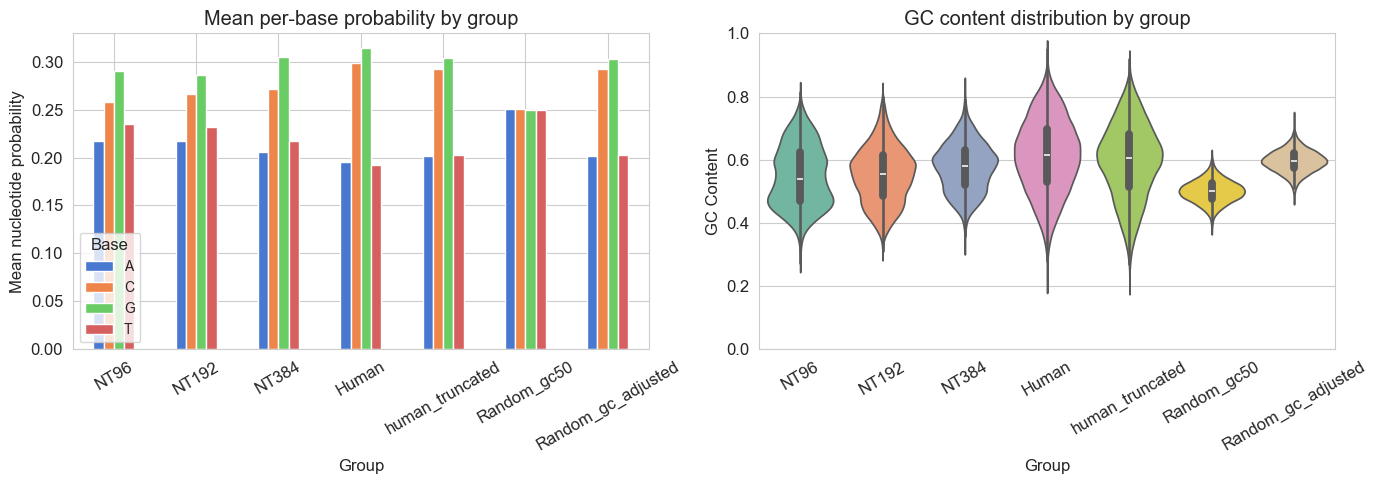

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: mean per-base probability, one bar group per nucleotide group
mean_by_group = nt_probs_df.groupby(GROUP_COL)[list(constants.DNABASES)].mean().reindex(GROUPS)
mean_by_group.plot(kind="bar", ax=axes[0], color=sns.color_palette("muted", n_colors=4))
axes[0].set_ylabel("Mean nucleotide probability")
axes[0].set_xlabel("Group")
axes[0].set_title("Mean per-base probability by group")
axes[0].tick_params(axis="x", rotation=30)
axes[0].legend(title="Base",loc="lower left", fontsize=10)

# Right: full distribution of GC content per group (not just the mean)
sns.violinplot(data=nt_probs_df, x=GROUP_COL, y="GC Content", order=GROUPS,
               hue=GROUP_COL, palette=PALETTE, legend=False, ax=axes[1])
axes[1].set_ylim(0, 1)
axes[1].set_title("GC content distribution by group")
axes[1].set_xlabel("Group")
axes[1].tick_params(axis="x", rotation=30)

fig.tight_layout()
plt.show()


## 5. Marker 2 — uORFs in reading frame

### Step 1 — write the function
Skipped: `src.rna_analysis.uORFs` and `src.rna_analysis.counts_concat_all` already do exactly what's
needed (frame-resolved uORF/ouORF counts and lengths, combined across start codons), so nothing new
to write here.

### Step 2 — apply to all the data
For each group, run `uORFs` once per start codon in `START_CODONS`, then combine those five result
tables with `counts_concat_all` (this mirrors how it's already done in `plots.ipynb`). This can be
slow on large datasets since `uORFs` scans every codon position per sequence per start codon.

In [16]:
uorf_frames = []
for g in GROUPS:
    sub = seqs_by_group[g]
    sub=swap_bases(sub, constants.RNABASES)
    uorfs=rna.uORFs(sub,'AUG')
    uorfs[GROUP_COL] = g
    uorf_frames.append(uorfs)
    print(uorfs)

          uORFs  ouORFs  mean_uORF_length  max_uORF_length  frame1_uORFs  \
SeqID                                                                      
seq_0       1.0     1.0            36.000             36.0           0.0   
seq_1       0.0     1.0             0.000              0.0           0.0   
seq_2       4.0     2.0            24.500             36.0           3.0   
seq_3       3.0     1.0            53.250             96.0           1.0   
seq_4       0.0     0.0             0.000              0.0           0.0   
...         ...     ...               ...              ...           ...   
seq_9995    6.0     1.0            52.125             75.0           0.0   
seq_9996    2.0     1.0            37.500             66.0           2.0   
seq_9997    0.0     0.0             0.000              0.0           0.0   
seq_9998    0.0     1.0             0.000              0.0           0.0   
seq_9999    4.0     0.0            37.500             54.0           1.0   

          f

In [17]:
uorf_df = pd.concat(uorf_frames)   # one row per sequence, across all six groups
uorf_df.columns

Index(['uORFs', 'ouORFs', 'mean_uORF_length', 'max_uORF_length',
       'frame1_uORFs', 'frame1_ouORFs', 'frame1_mean_uORF_length',
       'frame1_max_uORF_length', 'frame2_uORFs', 'frame2_ouORFs',
       'frame2_mean_uORF_length', 'frame2_max_uORF_length', 'frame3_uORFs',
       'frame3_ouORFs', 'frame3_mean_uORF_length', 'frame3_max_uORF_length',
       'Group'],
      dtype='object')

In [18]:
uorf_summary_cols = ['uORFs','frame1_ouORFs','mean_uORF_length','max_uORF_length']
uorf_summary = uorf_df.groupby(GROUP_COL)[uorf_summary_cols].mean().reindex(GROUPS)
uorf_summary


,uORFs,frame1_ouORFs,mean_uORF_length,max_uORF_length
Group,,,,
NT96,1.919800,0.251200,35.241453,49.377600
NT192,1.830700,0.256800,35.294088,49.057500
NT384,1.690700,0.255600,35.176009,47.877900
Human,2.019658,0.033152,28.548531,48.401819
human_truncated,1.150335,0.133613,26.404978,33.882844
Random_gc50,2.098400,0.245100,37.683644,53.865600
Random_gc_adjusted,1.422900,0.254700,37.182231,47.920500


### Step 3 — plot

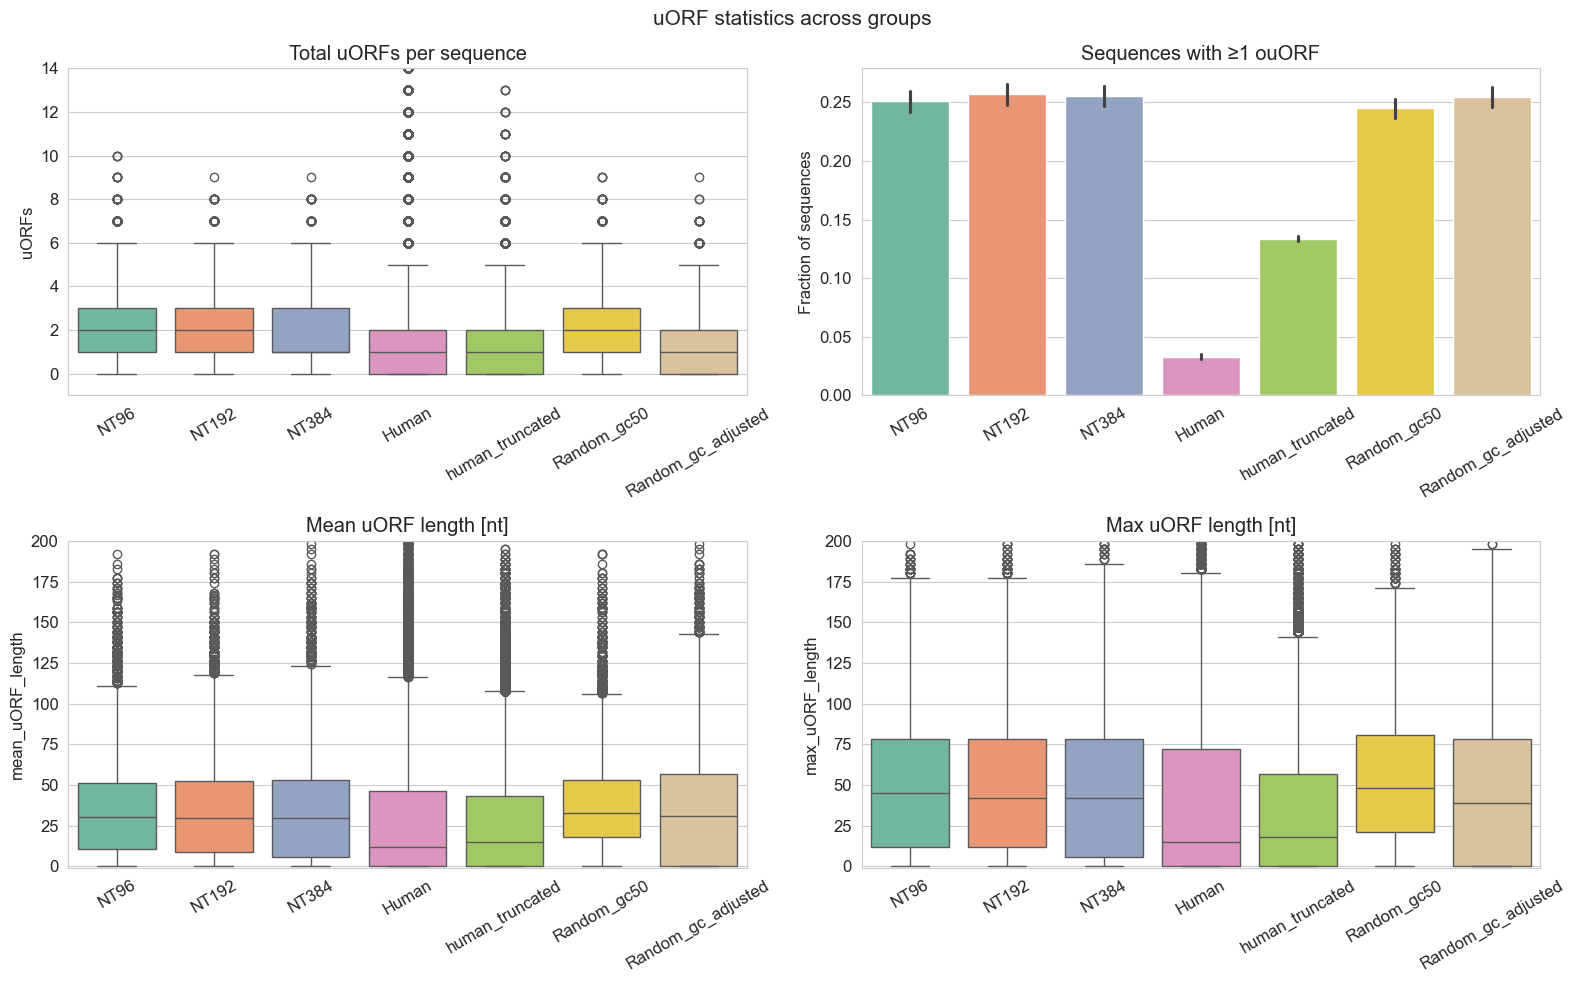

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

sns.boxplot(data=uorf_df, x=GROUP_COL, y="uORFs", order=GROUPS,
            hue=GROUP_COL, palette=PALETTE, legend=False, ax=axes[0, 0])
axes[0, 0].set_title("Total uORFs per sequence")
axes[0,0].set_ylim(-1, 14)

sns.barplot(data=uorf_df, x=GROUP_COL, y="frame1_ouORFs", order=GROUPS,
            hue=GROUP_COL, palette=PALETTE, legend=False,
            estimator=lambda x: (x > 0).mean(), ax=axes[0, 1])
axes[0, 1].set_title("Sequences with ≥1 ouORF")
axes[0, 1].set_ylabel("Fraction of sequences")

sns.boxplot(data=uorf_df, x=GROUP_COL, y="mean_uORF_length", order=GROUPS,
            hue=GROUP_COL, palette=PALETTE, legend=False, ax=axes[1, 0])
axes[1, 0].set_title("Mean uORF length [nt]")
axes[1,0].set_ylim(-1, 200)
sns.boxplot(data=uorf_df, x=GROUP_COL, y="max_uORF_length", order=GROUPS,
            hue=GROUP_COL, palette=PALETTE, legend=False, ax=axes[1, 1])
axes[1, 1].set_title("Max uORF length [nt]")
axes[1,1].set_ylim(-1, 200)
for ax in axes.flat:
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=30)

fig.suptitle("uORF statistics across groups", fontsize=15)
fig.tight_layout()
plt.show()


## 6. Marker 3 — Secondary structure / minimum free energy (MFE)

### Step 2 — apply to all the data
Groups are subsampled to `MFE_SAMPLE_SIZE` sequences first since ViennaRNA folding is the slowest
step in this notebook by far.

In [20]:
'''
mfe_frames = []
for g in GROUPS:
    sub  = seqs_by_group[g]
    total = len(sub)
    mfes = []
    rna.printProgressBar(0, total, prefix=f"{g}:", suffix="Complete", length=40)
    for i, seq in enumerate(sub[SEQ_COL]):
        mfes.append(vrna.fold(seq)[1])
        rna.printProgressBar(i + 1, total, prefix=f"{g}:", suffix="Complete", length=40)
    mfe_frames.append(pd.DataFrame({"mfe": mfes, GROUP_COL: g}, index=sub.index))

mfe_df = pd.concat(mfe_frames)
mfe_df.groupby(GROUP_COL)["mfe"].agg(["mean", "std", "count"]).reindex(GROUPS)
'''

'\nmfe_frames = []\nfor g in GROUPS:\n    sub  = seqs_by_group[g]\n    total = len(sub)\n    mfes = []\n    rna.printProgressBar(0, total, prefix=f"{g}:", suffix="Complete", length=40)\n    for i, seq in enumerate(sub[SEQ_COL]):\n        mfes.append(vrna.fold(seq)[1])\n        rna.printProgressBar(i + 1, total, prefix=f"{g}:", suffix="Complete", length=40)\n    mfe_frames.append(pd.DataFrame({"mfe": mfes, GROUP_COL: g}, index=sub.index))\n\nmfe_df = pd.concat(mfe_frames)\nmfe_df.groupby(GROUP_COL)["mfe"].agg(["mean", "std", "count"]).reindex(GROUPS)\n'

In [21]:
#mfe_df.to_csv("mfe_df.csv")

In [22]:
import os
os.getcwd()

'/Volumes/ag_ohler/jdemoli/bachelorgit'

In [23]:
mfe_df=pd.read_csv("mfe_df.csv")

In [24]:
for g in PLOT_GROUPS:
    sub = seqs_by_group[g]
    print(g,len(sub[SEQ_COL][0]))
    
        
        

NT96 200
NT192 200
NT384 200
human_truncated 200
Random_gc50 200
Random_gc_adjusted 200


/var/folders/9y/7_4kj0x536v6wlszx7nx0wb17rx8k_/T/ipykernel_12124/1698993803.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(g,len(sub[SEQ_COL][0]))


### Step 3 — plot

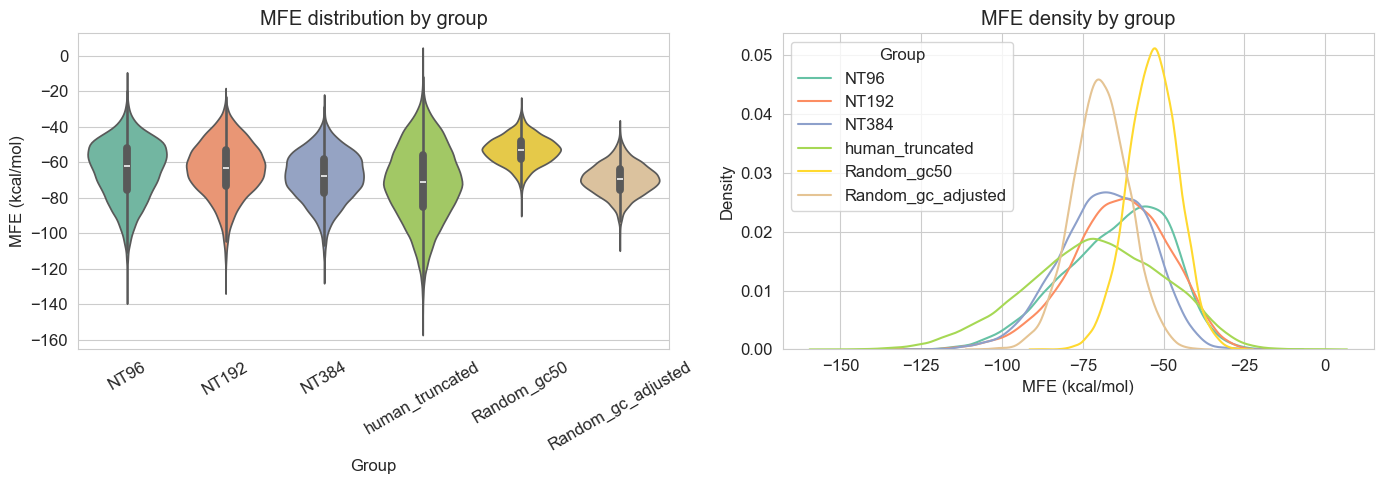

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.violinplot(data=mfe_df[mfe_df[GROUP_COL].isin(PLOT_GROUPS)], x=GROUP_COL, y="mfe",
               order=PLOT_GROUPS, hue=GROUP_COL, palette=PALETTE, legend=False, ax=axes[0])
axes[0].set_title("MFE distribution by group")
axes[0].set_ylabel("MFE (kcal/mol)")
axes[0].set_xlabel("Group")
axes[0].tick_params(axis="x", rotation=30)

for g in PLOT_GROUPS:
    sns.kdeplot(data=mfe_df[mfe_df[GROUP_COL] == g], x="mfe",
                label=g, color=PALETTE[g], ax=axes[1])
axes[1].set_title("MFE density by group")
axes[1].set_xlabel("MFE (kcal/mol)")
axes[1].legend(title="Group")

fig.tight_layout()
plt.show()

## 7. Marker 4 — Markov (dinucleotide transition) probabilities

### Step 1 — write the function
Skipped: `src.KLD_calculation.markov_matrix` (transition matrix) and `src.KLD_calculation.jsd`
(Jensen-Shannon divergence between matrices) already exist - nothing new to write.

### Step 2 — apply to all the data
Build one transition matrix per group, plus the underlying single-nucleotide probabilities for
reference.

In [26]:
markov_matrices = {}
single_probs = {}
for g in GROUPS:
    p_duplet, p_single, matrix = kldcalc.markov_matrix(seqs_by_group[g], seq_column=SEQ_COL)
    markov_matrices[g] = matrix     # 4x4 transition matrix, rows/cols ordered A,C,G,U
    single_probs[g] = p_single      # P(A), P(C), P(G), P(U) for this group

single_probs_df = pd.DataFrame(single_probs).T.reindex(GROUPS)
single_probs_df.index.name = GROUP_COL
single_probs_df


,A,C,G,U
Group,,,,
NT96,0.216968,0.258288,0.290002,0.234741
NT192,0.216799,0.265871,0.285676,0.231654
NT384,0.205734,0.271592,0.304973,0.217701
Human,0.205405,0.289332,0.301585,0.203677
human_truncated,0.201375,0.292513,0.303283,0.202829
Random_gc50,0.250063,0.250231,0.249727,0.249978
Random_gc_adjusted,0.201374,0.292772,0.302969,0.202886


In [27]:
def joint_probability(seq, matrix, init_probs):
    """
    Vectorised version — no Python loop over sequence positions.
    matrix should be the raw (4,4) numpy array from markov_matrices.
    """
    EPS      = 1e-10
    base_lut = np.zeros(128, dtype=np.int64)
    for i, b in enumerate(constants.RNABASES):
        base_lut[ord(b)] = i

    encoded  = base_lut[np.frombuffer(seq.encode(), dtype=np.uint8)]
    log_prob = np.log(init_probs[seq[0]] + EPS)
    log_prob += np.sum(np.log(matrix[encoded[:-1], encoded[1:]] + EPS))

    return log_prob

In [28]:
ref_matrix = markov_matrices["human_truncated"]
ref_single = single_probs["human_truncated"]
lp_df = pd.concat([
    seqs_by_group[g].assign(
        joint_probability=seqs_by_group[g][SEQ_COL].apply(
            lambda seq: joint_probability(seq, ref_matrix, ref_single)
        )
    )
    for g in PLOT_GROUPS
])

### Step 3 — plot

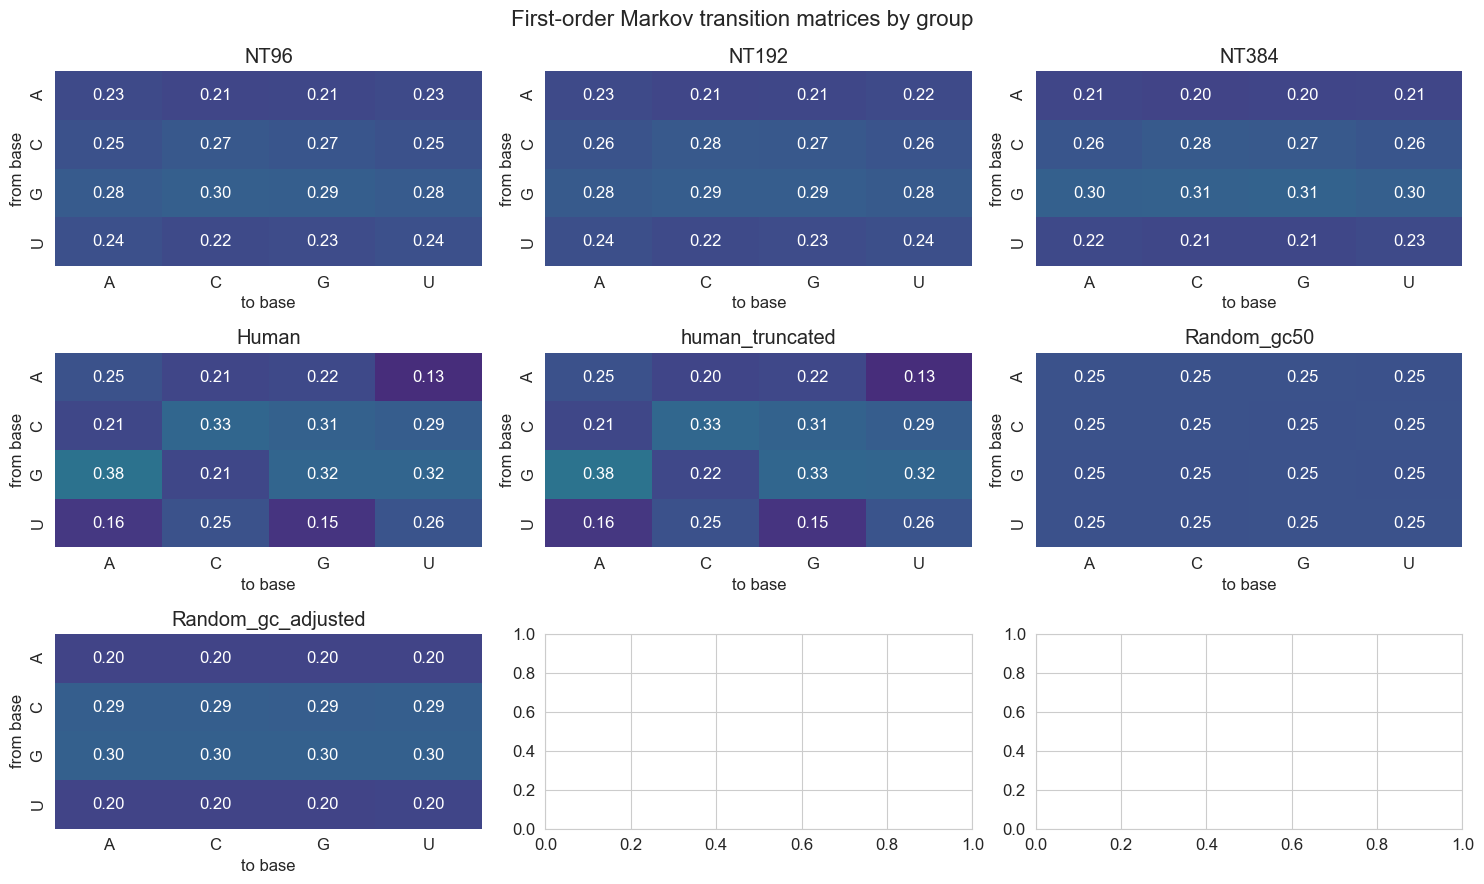

In [29]:
fig, axes = plt.subplots(3, 3, figsize=(15, 9))
bases = list(constants.RNABASES)

for ax, g in zip(axes.flat, GROUPS):
    sns.heatmap(markov_matrices[g], annot=True, fmt=".2f", cmap="viridis",
                xticklabels=bases, yticklabels=bases, vmin=0, vmax=1,
                cbar=False, ax=ax)
    ax.set_title(g)
    ax.set_xlabel("to base")
    ax.set_ylabel("from base")

fig.suptitle("First-order Markov transition matrices by group", fontsize=16)
fig.tight_layout()
plt.show()


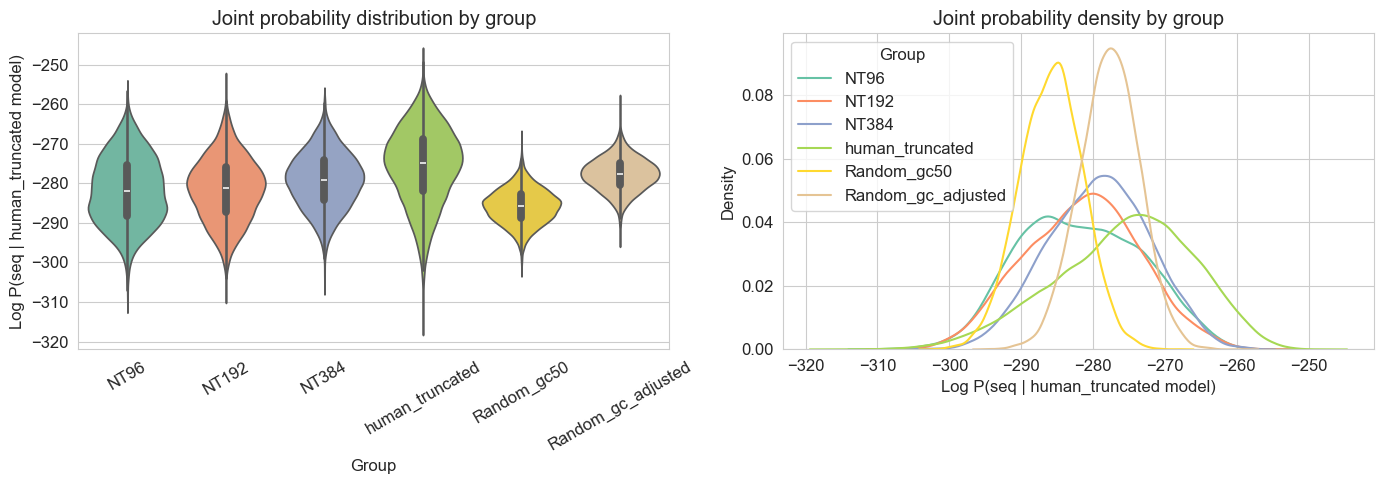

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.violinplot(data=lp_df, x=GROUP_COL, y="joint_probability", order=PLOT_GROUPS,
               hue=GROUP_COL, palette=PALETTE, legend=False, ax=axes[0])
axes[0].set_title("Joint probability distribution by group")
axes[0].set_ylabel("Log P(seq | human_truncated model)")
axes[0].set_xlabel("Group")
axes[0].tick_params(axis="x", rotation=30)

for g in PLOT_GROUPS:
    sns.kdeplot(data=lp_df[lp_df[GROUP_COL] == g], x="joint_probability",
                label=g, color=PALETTE[g], ax=axes[1])
axes[1].set_title("Joint probability density by group")
axes[1].set_xlabel("Log P(seq | human_truncated model)")
axes[1].legend(title="Group")

fig.tight_layout()
plt.show()

In [31]:
jp_summary = lp_df.groupby(GROUP_COL)["joint_probability"].agg(["mean", "std", "count"])
jp_summary.columns = ["Mean log P", "Std log P", "N sequences"]
jp_summary = jp_summary.reindex(PLOT_GROUPS)
jp_summary.style.background_gradient(cmap="Blues", axis=0)

,Mean log P,Std log P,N sequences
Group,,,
NT96,-281.763581,8.486268,10000
NT192,-281.495892,7.982133,10000
NT384,-279.210985,7.063007,10000
human_truncated,-275.687026,9.648388,67935
Random_gc50,-285.811583,4.381960,10000
Random_gc_adjusted,-277.747735,4.175643,10000


# 8. Marker 5 - k-mer analysis

In [32]:
def kmer_frequencies(seqs_df, k, seq_col=SEQ_COL):
    """
    Compute relative k-mer frequencies for every sequence in seqs_df.

    Uses vectorised base-4 polynomial encoding (stride_tricks + bincount)
    so the inner loop over sequence positions runs in C regardless of k.

    Parameters
    ----------
    seqs_df : pd.DataFrame
        Must contain a column named seq_col with RNA sequences (A/C/G/U).
    k : int
        K-mer length. Works for any k, though memory grows as 4^k columns.
    seq_col : str
        Name of the sequence column. Defaults to SEQ_COL.

    Returns
    -------
    pd.DataFrame, shape (n_seqs, 4^k)
        Rows are sequences (same index as seqs_df), columns are all 4^k
        k-mers in alphabetical order. Each value is the fraction of sliding
        windows of length k in which that k-mer appears.
    """
    # --- fixed lookup tables built once per call ----------------------------
    n_kmers     = 4 ** k
    all_kmers   = ["".join(p) for p in product(constants.RNABASES, repeat=k)]
    powers      = (4 ** np.arange(k - 1, -1, -1)).astype(np.int64)

    # Map ASCII byte value -> base index (A=0, C=1, G=2, U=3); unknown bases -> 0
    base_lut = np.zeros(128, dtype=np.int64)
    for idx, base in enumerate(constants.RNABASES):
        base_lut[ord(base)] = idx

    # --- per-sequence counting ----------------------------------------------
    rows = []
    for seq in seqs_df[seq_col]:
        encoded   = base_lut[np.frombuffer(seq.encode(), dtype=np.uint8)]
        n_windows = len(encoded) - k + 1

        if n_windows < 1:
            rows.append(np.zeros(n_kmers))
            continue

        windows   = np.lib.stride_tricks.sliding_window_view(encoded, k)  # (n_windows, k)
        indices   = windows @ powers                                        # (n_windows,)
        counts    = np.bincount(indices, minlength=n_kmers)
        rows.append(counts / n_windows)

    return pd.DataFrame(rows, index=seqs_df.index, columns=all_kmers)

In [33]:
from itertools import product

ALL_3MERS = ["".join(p) for p in product(constants.RNABASES, repeat=3)]
ALL_6MERS = ["".join(p) for p in product(constants.RNABASES, repeat=6)]

kmer3_frames = []
kmer6_frames = []
for g in GROUPS:
    kmer3_frames.append(kmer_frequencies(seqs_by_group[g], k=3).assign(**{GROUP_COL: g}))
    kmer6_frames.append(kmer_frequencies(seqs_by_group[g], k=6).assign(**{GROUP_COL: g}))

kmer3_df = pd.concat(kmer3_frames)
kmer6_df = pd.concat(kmer6_frames)

mean_kmer3 = kmer3_df.groupby(GROUP_COL)[ALL_3MERS].mean().reindex(GROUPS)
mean_kmer6 = kmer6_df.groupby(GROUP_COL)[ALL_6MERS].mean().reindex(GROUPS)

print(f"kmer3_df shape: {kmer3_df.shape}")
print(f"kmer6_df shape: {kmer6_df.shape}")

KeyboardInterrupt: 

In [ ]:
kmer3_df.to_csv("kmer3_df.csv")
kmer6_df.to_csv("kmer6_df.csv")

In [2]:
kmer3_df=pd.read_csv("kmer3_df.csv")
kmer6_df=pd.read_csv("kmer6_df.csv")

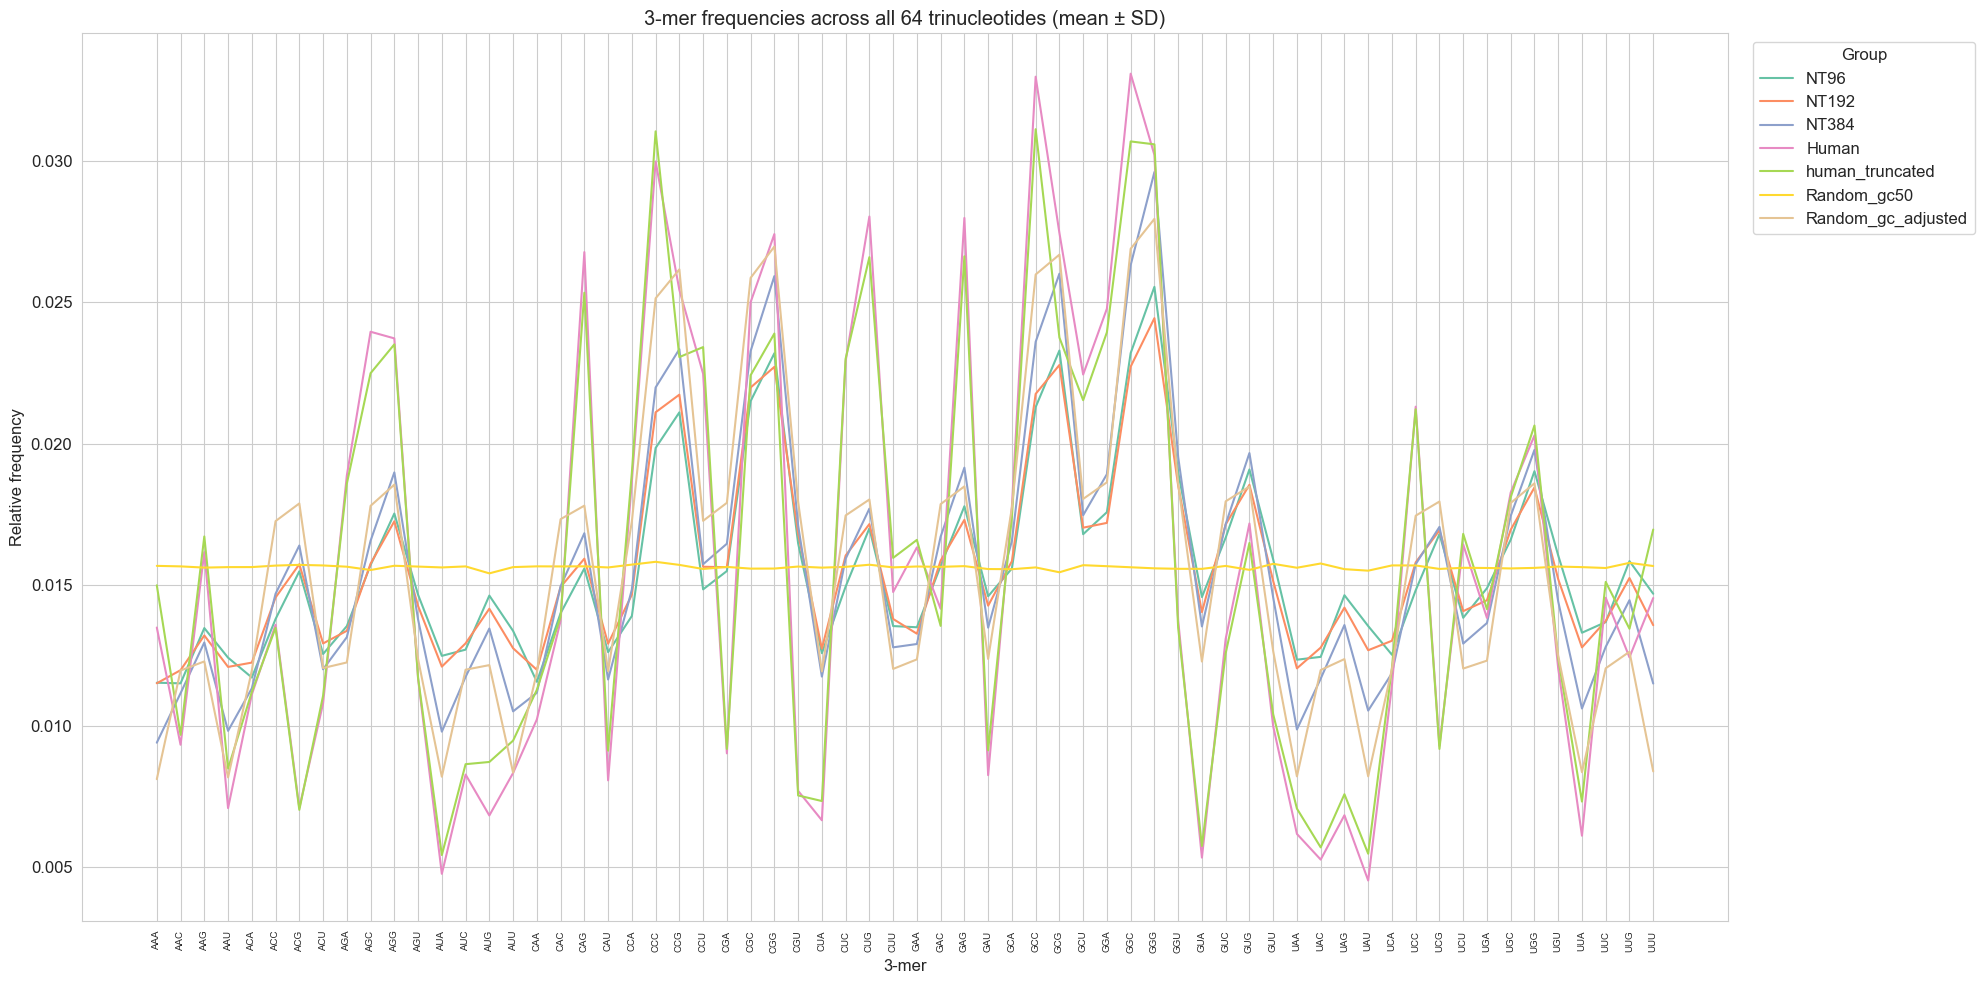

In [10]:
from itertools import product
fig, ax = plt.subplots(figsize=(20, 10))
ALL_3MERS = ["".join(p) for p in product(constants.RNABASES, repeat=3)]
ALL_6MERS = ["".join(p) for p in product(constants.RNABASES, repeat=6)]
x = np.arange(len(ALL_3MERS))
for g in GROUPS:
    group_data = kmer3_df.loc[kmer3_df[GROUP_COL] == g, ALL_3MERS]
    means = group_data.mean()
    sds   = group_data.std()
    ax.plot(x, means, label=g, color=PALETTE[g], linewidth=1.5)
    #ax.fill_between(x, means - sds, means + sds, color=PALETTE[g], alpha=0.15)

ax.set_xticks(x)
ax.set_xticklabels(ALL_3MERS, rotation=90, fontsize=7)
ax.set_xlabel("3-mer")
ax.set_ylabel("Relative frequency")
ax.set_title("3-mer frequencies across all 64 trinucleotides (mean ± SD)")
ax.legend(title="Group", bbox_to_anchor=(1.01, 1), loc="upper left")
fig.tight_layout()
plt.show()

In [8]:
import umap
import plotly.express as px
ALL_3MERS = ["".join(p) for p in product(constants.RNABASES, repeat=3)]
ALL_6MERS = ["".join(p) for p in product(constants.RNABASES, repeat=6)]
X6      = kmer6_df[ALL_6MERS].values
labels6 = kmer6_df[GROUP_COL].values

reducer6   = umap.UMAP(n_neighbors=15, min_dist=0.1, metric="cosine",
                       n_components=3, random_state=RANDOM_SEED)
embedding6 = reducer6.fit_transform(X6)

emb6_df = pd.DataFrame(embedding6, columns=["UMAP 1", "UMAP 2", "UMAP 3"])
emb6_df[GROUP_COL] = labels6

fig = px.scatter_3d(emb6_df, x="UMAP 1", y="UMAP 2", z="UMAP 3",
                    color=GROUP_COL, color_discrete_map=PALETTE, opacity=0.7,
                    title="UMAP of 6-mer frequencies (3D, cosine metric)")
fig.show()

/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


## 9. Cross-marker summary

A compact overview combining one headline statistic per marker for each group.

In [ ]:
summary = pd.DataFrame(index=GROUPS)
summary["GC content (mean)"] = nt_probs_df.groupby(GROUP_COL)["GC Content"].mean().reindex(GROUPS)
summary["uORFs per seq (mean)"] = uorf_df.groupby(GROUP_COL)["uORFs"].mean().reindex(GROUPS)
summary["ouORFs per seq (mean)"] = uorf_df.groupby(GROUP_COL)["frame1_ouORFs"].mean().reindex(GROUPS)
if MFE_AVAILABLE and len(mfe_df) > 0:
    summary["MFE per nt (mean)"] = mfe_df.groupby(GROUP_COL)["sliding window mfe"].mean().reindex(GROUPS)
#summary["JSD vs human (Markov)"] = jsd_matrix["human"].reindex(GROUPS)

summary.style.background_gradient(cmap="Blues", axis=0)


---
**Open items:**
- Tell me how `NT96`/`NT192`/`NT384` should actually be sourced (file + column/ID rule, like the
  `transcript_id`/`ENST` rule used for `human_truncated`) and section 3c gets swapped for the real thing.
- Once `data/new_dataset.csv` and `data/delivered_twist_pool.csv` are in place, re-run from section 3 —
  everything downstream already points at `seqs_by_group`, so nothing else needs to change.
- Increase/disable `MFE_SAMPLE_SIZE` once you've confirmed the pipeline behaves as expected on the full data.
